In [1]:
# run "pip install -r requirements.txt" if you need to redownload these

from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parent)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
from data_loaders.masterTestDataLoader import loadAndSaveData
from data_loaders.InstrumentDataset import InstrumentDataset
from torch.utils.data import DataLoader
import pandas as pd
import torch
import numpy as np

In [ ]:
"""
FILTER OUT STEPS 6-20 (ONLY 1/4 OF THE STEP DATA IS REQUIRED, AS TECHNICALLY EVERYTHING ELSE IS JUST A PROJECTION OF THIS 1/4)
    -> S1 - S20 :: KEEP S1-S5 only for each

DONE BY masterDataLoader.py
"""

# save data
loadAndSaveData(root_dir="E:\\HeaRTLabInstrumentTestData", csvSave="..\\data\\metadataTest.csv")

# Load the data into a pandas dataframe [SUCCESSFULLY LOADS ALL IMAGES AND METADATA]
df = pd.DataFrame(pd.read_csv("..\\data\\metadataTest.csv"))

# MAKE TABLE EVEN MORE CONCISE BY EDITING THE masterDataLoader.py file
# SX - step [remove]
# L - lights that are on
# B - brightness

"""
FILTER OUT SIDE CAMERA DATA

CHANGE THESE WHEN NEEDED
"""
instruments = [
    "Needle Holder, Mayo-Hegar Straight Carb-bite Serrated Jaws 8in",
    "Needle Holder, Ryder Straight Carb-bite Serrated Jaws 8in", 
    "Sponge Holding Forceps, Foerster Straight Serrated 9.5in"
]
camera = ["top_camera"]
orientation = ["right_side_up"]
state = ["static_closed", "static_open"]
background = ["blue"]

df_filtered_TEST = df[
    (df["instrument"].isin(instruments)) &
    (df["camera"].isin(camera)) &
    (df["orientation"].isin(orientation)) &
    (df["state"].isin(state)) &
    (df["background"].isin(background))
]

# Create label map
label_map = {name: i for i, name in enumerate(instruments)}

# Assign labels
df_filtered_TEST["label"] = df_filtered_TEST["instrument"].map(label_map)

df_filtered_TEST

,image_path,instrument,background,orientation,state,lights,brightness,camera,label
0,E:\HeaRTLabInstrumentTestData\Sponge Holding F...,"Sponge Holding Forceps, Foerster Straight Serr...",blue,right_side_up,static_closed,L1,80,top_camera,2
1,E:\HeaRTLabInstrumentTestData\Sponge Holding F...,"Sponge Holding Forceps, Foerster Straight Serr...",blue,right_side_up,static_closed,L2,80,top_camera,2
2,E:\HeaRTLabInstrumentTestData\Sponge Holding F...,"Sponge Holding Forceps, Foerster Straight Serr...",blue,right_side_up,static_closed,L3,80,top_camera,2
3,E:\HeaRTLabInstrumentTestData\Sponge Holding F...,"Sponge Holding Forceps, Foerster Straight Serr...",blue,right_side_up,static_closed,L4,80,top_camera,2
4,E:\HeaRTLabInstrumentTestData\Sponge Holding F...,"Sponge Holding Forceps, Foerster Straight Serr...",blue,right_side_up,static_closed,L1_2,80,top_camera,2
...,...,...,...,...,...,...,...,...,...
61807,"E:\HeaRTLabInstrumentTestData\Needle Holder, R...","Needle Holder, Ryder Straight Carb-bite Serrat...",blue,right_side_up,static_open,L1_2_3,200,top_camera,1
61808,"E:\HeaRTLabInstrumentTestData\Needle Holder, R...","Needle Holder, Ryder Straight Carb-bite Serrat...",blue,right_side_up,static_open,L2_3_4,200,top_camera,1
61809,"E:\HeaRTLabInstrumentTestData\Needle Holder, R...","Needle Holder, Ryder Straight Carb-bite Serrat...",blue,right_side_up,static_open,L1_3_4,200,top_camera,1
61810,"E:\HeaRTLabInstrumentTestData\Needle Holder, R...","Needle Holder, Ryder Straight Carb-bite Serrat...",blue,right_side_up,static_open,L1_2_4,200,top_camera,1


In [7]:
# normal test
testDatasetNormal = InstrumentDataset(df_filtered_TEST, apply_occlusion=False)

# occluded test
testDatasetOccluded = InstrumentDataset(df_filtered_TEST, apply_occlusion=True)

In [8]:
# create the test loaders
testLoaderNormal = DataLoader(testDatasetNormal, batch_size=32, shuffle=False)
testLoaderOccluded = DataLoader(testDatasetOccluded, batch_size=32, shuffle=False)

In [9]:
def evaluate_model(loader, model, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [10]:
import torch.nn
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# create the resnet model
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# replace final layer
model.fc = nn.Linear(model.fc.in_features, 3)

# initialize model in device (preferably GPU)
model = model.to(device)

# confirmation
print("MODEL INITIALIZED!")

Using: cuda
MODEL INITIALIZED!


In [11]:
abbrev_labels = {
    "Needle Holder, Mayo-Hegar Straight Carb-bite Serrated Jaws 8in": "NH-MH",
    "Needle Holder, Ryder Straight Carb-bite Serrated Jaws 8in": "NH-R",
    "Sponge Holding Forceps, Foerster Straight Serrated 9.5in": "SHF"
}

display_labels = [
    abbrev_labels[name]
    for name in label_map.keys()
]

## classifierModel.ipynb test with metadataTest.csv

In [ ]:
model.load_state_dict(torch.load('models\\regularClassifierModel_weights.pth', weights_only=True))
model.eval()

In [ ]:
labels_normal, preds_normal = evaluate_model(testLoaderNormal, model, device)
labels_occ, preds_occ = evaluate_model(testLoaderOccluded, model, device)

In [ ]:
cm_normal = confusion_matrix(labels_normal, preds_normal)
cm_occ = confusion_matrix(labels_occ, preds_occ)

In [ ]:
disp1 = ConfusionMatrixDisplay(cm_normal, display_labels=display_labels)
disp1.plot(cmap="Blues")
plt.title("Normal Test")
plt.show()

In [ ]:
disp2 = ConfusionMatrixDisplay(cm_occ, display_labels=display_labels)
disp2.plot(cmap="Reds")
plt.title("Occluded Test")
plt.show()

In [ ]:
acc_normal = np.mean(np.array(labels_normal) == np.array(preds_normal))
acc_occ = np.mean(np.array(labels_occ) == np.array(preds_occ))

print(f"Normal Accuracy: {acc_normal * 100:.2f}%")
print(f"Occluded Accuracy: {acc_occ * 100:.2f}%")

## augmentedConsistentBGClassifier.ipynb test with metadataTest.csv

In [ ]:
model.load_state_dict(torch.load('models\\augmentedConsistentBG_weights.pth', weights_only=True))
model.eval()

In [ ]:
labels_normal, preds_normal = evaluate_model(testLoaderNormal, model, device)
labels_occ, preds_occ = evaluate_model(testLoaderOccluded, model, device)

In [ ]:
cm_normal = confusion_matrix(labels_normal, preds_normal)
cm_occ = confusion_matrix(labels_occ, preds_occ)

In [ ]:
disp1 = ConfusionMatrixDisplay(cm_normal, display_labels=display_labels)
disp1.plot(cmap="Blues")
plt.title("Normal Test")
plt.show()

In [ ]:
disp2 = ConfusionMatrixDisplay(cm_occ, display_labels=display_labels)
disp2.plot(cmap="Reds")
plt.title("Occluded Test")
plt.show()

In [ ]:
acc_normal = np.mean(np.array(labels_normal) == np.array(preds_normal))
acc_occ = np.mean(np.array(labels_occ) == np.array(preds_occ))

print(f"Normal Accuracy: {acc_normal * 100:.2f}%")
print(f"Occluded Accuracy: {acc_occ * 100:.2f}%")

## augmentedRandomBGClassifier.ipynb test with metadataTest.csv

In [ ]:
model.load_state_dict(torch.load('models\\augmentedRandomBG_weights.pth', weights_only=True))
model.eval()

In [ ]:
labels_normal, preds_normal = evaluate_model(testLoaderNormal, model, device)
labels_occ, preds_occ = evaluate_model(testLoaderOccluded, model, device)

In [ ]:
cm_normal = confusion_matrix(labels_normal, preds_normal)
cm_occ = confusion_matrix(labels_occ, preds_occ)

In [ ]:
disp1 = ConfusionMatrixDisplay(cm_normal, display_labels=display_labels)
disp1.plot(cmap="Blues")
plt.title("Normal Test")
plt.show()

In [ ]:
disp2 = ConfusionMatrixDisplay(cm_occ, display_labels=display_labels)
disp2.plot(cmap="Reds")
plt.title("Occluded Test")
plt.show()

In [ ]:
acc_normal = np.mean(np.array(labels_normal) == np.array(preds_normal))
acc_occ = np.mean(np.array(labels_occ) == np.array(preds_occ))

print(f"Normal Accuracy: {acc_normal * 100:.2f}%")
print(f"Occluded Accuracy: {acc_occ * 100:.2f}%")

## IMPORTANT: ACBG_ConvNeXt.ipynb test with metadataTest.csv

In [7]:
import timm

In [8]:
# create ConvNeXt model (must MATCH training exactly)
model = timm.create_model('convnext_tiny', pretrained=False, num_classes=3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [9]:
# load your trained ConvNeXt weights
model.load_state_dict(torch.load('models\\augmentedConsistentBG_ConvNeXT_weights.pth', map_location=device))
model.eval()

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)


In [10]:
# evaluate
labels_normal, preds_normal = evaluate_model(testLoaderNormal, model, device)
labels_occ, preds_occ = evaluate_model(testLoaderOccluded, model, device)

In [11]:
cm_normal = confusion_matrix(labels_normal, preds_normal)
cm_occ = confusion_matrix(labels_occ, preds_occ)

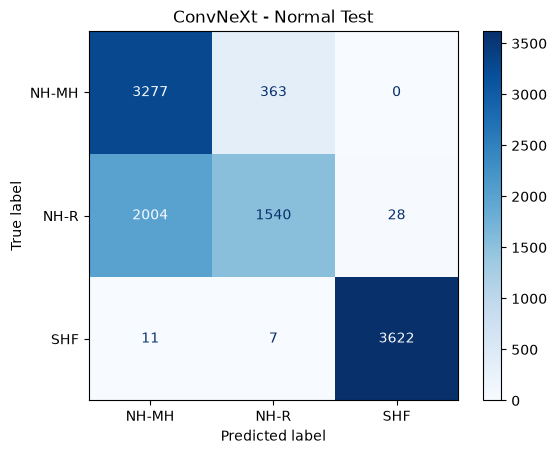

In [14]:
disp1 = ConfusionMatrixDisplay(cm_normal, display_labels=display_labels)
disp1.plot(cmap="Blues")
plt.title("ConvNeXt - Normal Test")
plt.show()

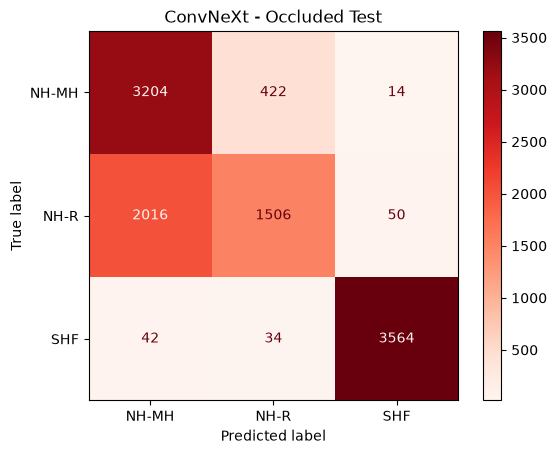

In [15]:
disp2 = ConfusionMatrixDisplay(cm_occ, display_labels=display_labels)
disp2.plot(cmap="Reds")
plt.title("ConvNeXt - Occluded Test")
plt.show()

In [1]:
# accuracies
acc_normal = np.mean(np.array(labels_normal) == np.array(preds_normal))
acc_occ = np.mean(np.array(labels_occ) == np.array(preds_occ))

print(f"ConvNeXt Normal Accuracy: {acc_normal * 100:.2f}%")
print(f"ConvNeXt Occluded Accuracy: {acc_occ * 100:.2f}%")

NameError: name 'np' is not defined

## IMPORTANT: ARBG_ConvNeXt.ipynb test with metadataTest.csv

In [10]:
import timm

In [11]:
# create ConvNeXt model (must MATCH training exactly)
model = timm.create_model('convnext_tiny', pretrained=False, num_classes=3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [12]:
# load your trained ConvNeXt weights
model.load_state_dict(torch.load('models\\augmentedConsistentBG_ConvNeXT_weights.pth', map_location=device))
model.eval()

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)


In [12]:
# evaluate
labels_normal, preds_normal = evaluate_model(testLoaderNormal, model, device)
labels_occ, preds_occ = evaluate_model(testLoaderOccluded, model, device)

In [13]:
cm_normal = confusion_matrix(labels_normal, preds_normal)
cm_occ = confusion_matrix(labels_occ, preds_occ)

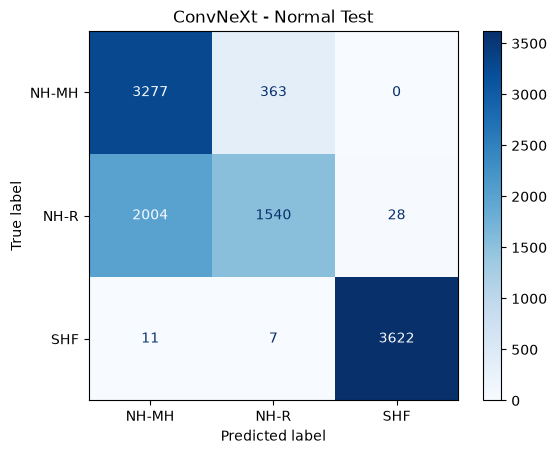

In [14]:
disp1 = ConfusionMatrixDisplay(cm_normal, display_labels=display_labels)
disp1.plot(cmap="Blues")
plt.title("ConvNeXt - Normal Test")
plt.show()

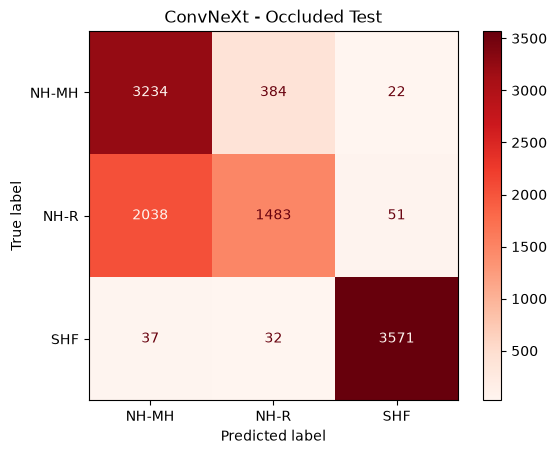

In [15]:
disp2 = ConfusionMatrixDisplay(cm_occ, display_labels=display_labels)
disp2.plot(cmap="Reds")
plt.title("ConvNeXt - Occluded Test")
plt.show()

In [16]:
# accuracies
acc_normal = np.mean(np.array(labels_normal) == np.array(preds_normal))
acc_occ = np.mean(np.array(labels_occ) == np.array(preds_occ))

print(f"ConvNeXt Normal Accuracy: {acc_normal * 100:.2f}%")
print(f"ConvNeXt Occluded Accuracy: {acc_occ * 100:.2f}%")

ConvNeXt Normal Accuracy: 77.76%
ConvNeXt Occluded Accuracy: 76.37%


## IMPORTANT: ACBG_Swin.ipynb test with metadataTest.csv

In [13]:
import timm

In [18]:
# create ConvNeXt model (must MATCH training exactly)
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [19]:
# load your trained ConvNeXt weights
model.load_state_dict(torch.load('models\\augmentedConsistentBG_Swin_weights.pth', map_location=device))
model.eval()

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [20]:
# evaluate
labels_normal, preds_normal = evaluate_model(testLoaderNormal, model, device)
labels_occ, preds_occ = evaluate_model(testLoaderOccluded, model, device)

In [21]:
cm_normal = confusion_matrix(labels_normal, preds_normal)
cm_occ = confusion_matrix(labels_occ, preds_occ)

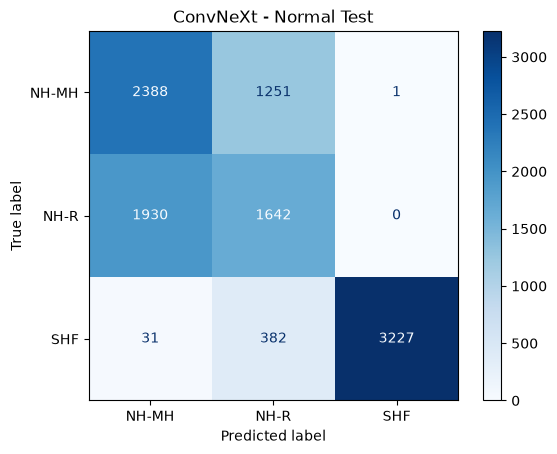

In [22]:
disp1 = ConfusionMatrixDisplay(cm_normal, display_labels=display_labels)
disp1.plot(cmap="Blues")
plt.title("ConvNeXt - Normal Test")
plt.show()

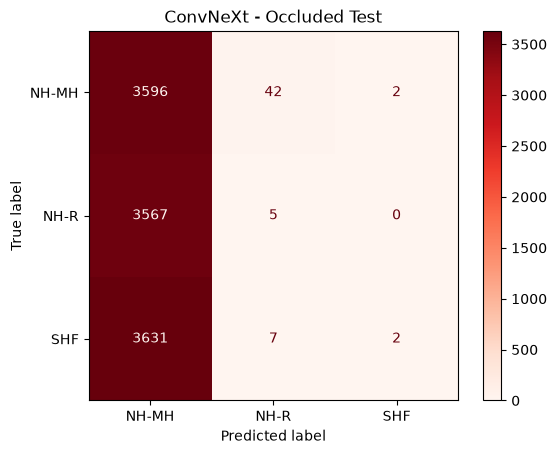

In [ ]:
disp2 = ConfusionMatrixDisplay(cm_occ, display_labels=display_labels)
disp2.plot(cmap="Reds")
plt.title("ConvNeXt - Occluded Test")
plt.show()

# WRONG CONFUSION MATRIX SHOWN HERE! DONT PANIC! I ACCIDENTALLY RAN THIS AFTER RUNNING THE RANDOM BG MODEL

In [25]:
# accuracies
acc_normal = np.mean(np.array(labels_normal) == np.array(preds_normal))
acc_occ = np.mean(np.array(labels_occ) == np.array(preds_occ))

print(f"ConvNeXt Normal Accuracy: {acc_normal * 100:.2f}%")
print(f"ConvNeXt Occluded Accuracy: {acc_occ * 100:.2f}%")

ConvNeXt Normal Accuracy: 66.87%
ConvNeXt Occluded Accuracy: 66.54%


## IMPORTANT: ARBG_Swin.ipynb test with metadataTest.csv

In [2]:
import timm

c:\Users\p0prak03\OneDrive - University of Louisville\Desktop\Medical Tool Classification\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# create ConvNeXt model (must MATCH training exactly)
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [4]:
# load your trained ConvNeXt weights
model.load_state_dict(torch.load('models\\augmentedRandomBG_Swin_weights.pth', map_location=device))
model.eval()

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [12]:
# evaluate
labels_normal, preds_normal = evaluate_model(testLoaderNormal, model, device)
labels_occ, preds_occ = evaluate_model(testLoaderOccluded, model, device)

In [13]:
cm_normal = confusion_matrix(labels_normal, preds_normal)
cm_occ = confusion_matrix(labels_occ, preds_occ)

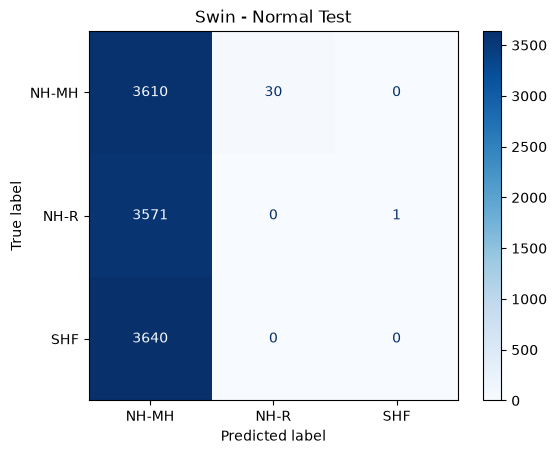

In [20]:
disp1 = ConfusionMatrixDisplay(cm_normal, display_labels=display_labels)
disp1.plot(cmap="Blues")
plt.title("Swin - Normal Test")
plt.show()

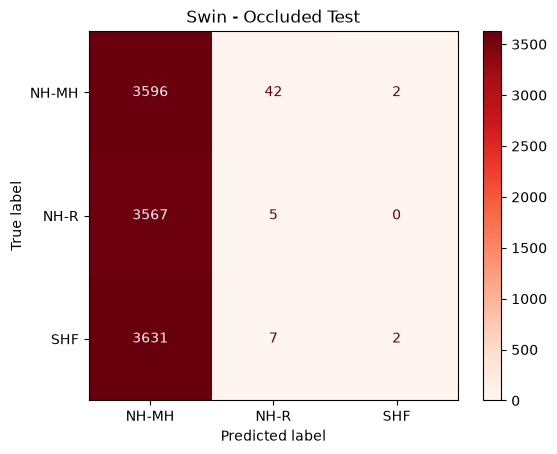

In [21]:
disp2 = ConfusionMatrixDisplay(cm_occ, display_labels=display_labels)
disp2.plot(cmap="Reds")
plt.title("Swin - Occluded Test")
plt.show()

In [19]:
# accuracies
acc_normal = np.mean(np.array(labels_normal) == np.array(preds_normal))
acc_occ = np.mean(np.array(labels_occ) == np.array(preds_occ))

print(f"ConvNeXt Normal Accuracy: {acc_normal * 100:.2f}%")
print(f"ConvNeXt Occluded Accuracy: {acc_occ * 100:.2f}%")

ConvNeXt Normal Accuracy: 33.27%
ConvNeXt Occluded Accuracy: 33.20%
